<a href="https://colab.research.google.com/github/hevendra630/KMeans_ImageCompression_Final/blob/main/Kmeans_imageCompression_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 📌 K-Means Image Compression — Full Colab Notebook
This notebook performs image compression using K-Means clustering and includes EDA, tuning, evaluation metrics, comparison, and download functionality.


Objective:

In [ ]:
## 🎯 1 — Objective & Problem Statement
**Goal:** Reduce the number of colors in an image by clustering similar RGB values using **K-Means**.

This is useful for:
- Image compression
- Reducing storage size
- Faster transmission
- Simplifying images for ML applications


Importing:


In [1]:
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import time
import math
from google.colab import files

plt.rcParams['figure.figsize'] = (8,5)


Taking input image:


Upload an image to compress:


Saving Screenshot 2024-11-25 224952.png to Screenshot 2024-11-25 224952.png
Image shape: (949, 1355, 3)


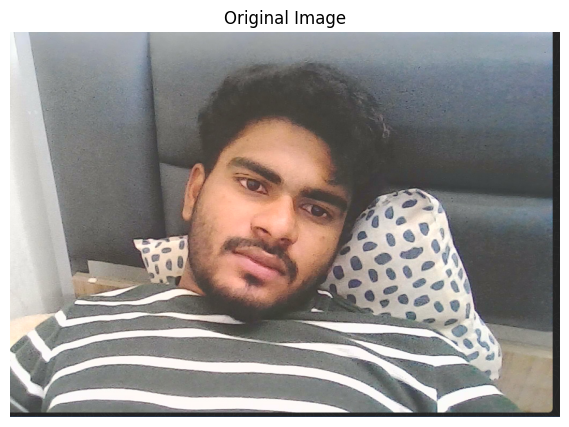

In [2]:
print("Upload an image to compress:")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
img = Image.open(io.BytesIO(uploaded[file_name])).convert("RGB")
img_np = np.array(img)

plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")

h, w, c = img_np.shape
print("Image shape:", img_np.shape)


Preprocessing:

In [3]:
pixels = img_np.reshape(-1, 3)

SAMPLE_SIZE = 20000
if len(pixels) > SAMPLE_SIZE:
    idx = np.random.choice(len(pixels), SAMPLE_SIZE, replace=False)
    sample_pixels = pixels[idx]
else:
    sample_pixels = pixels

print("Total pixels:", len(pixels))
print("Sample used:", len(sample_pixels))


Total pixels: 1285895
Sample used: 20000


EDA:


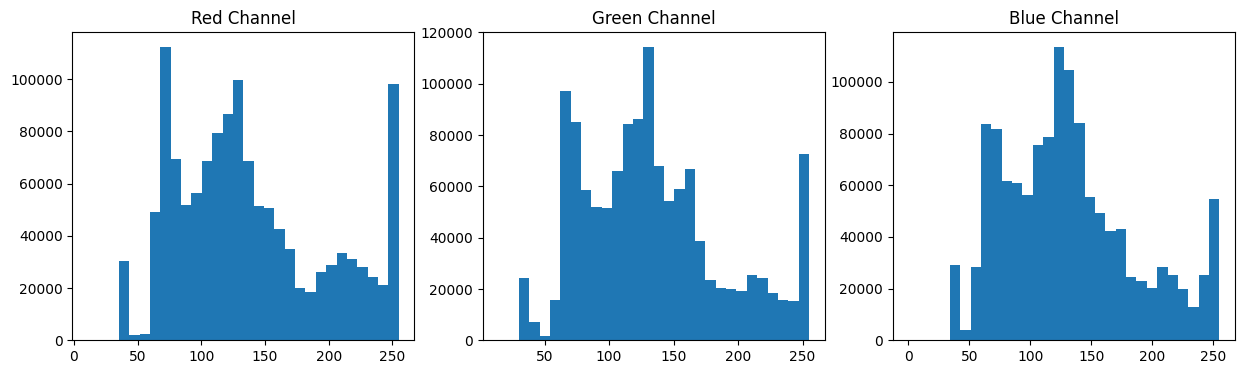

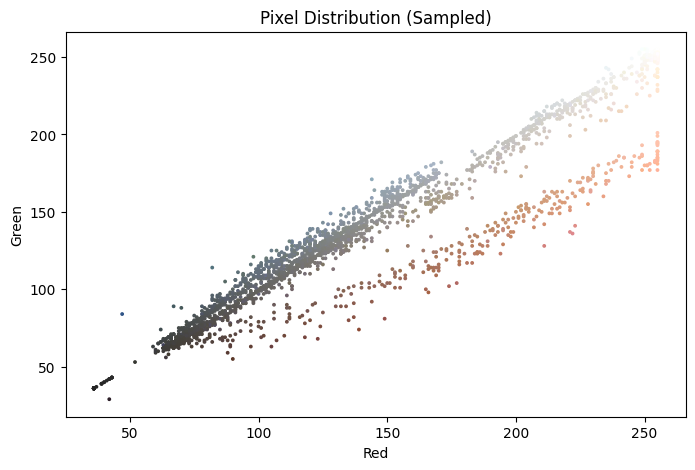

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].hist(pixels[:,0], bins=30); ax[0].set_title("Red Channel")
ax[1].hist(pixels[:,1], bins=30); ax[1].set_title("Green Channel")
ax[2].hist(pixels[:,2], bins=30); ax[2].set_title("Blue Channel")
plt.show()

subset = sample_pixels[:2500]
plt.scatter(subset[:,0], subset[:,1], s=3, c=subset/255)
plt.xlabel("Red"); plt.ylabel("Green")
plt.title("Pixel Distribution (Sampled)")
plt.show()


Elbow Method:


K=2, inertia=64989452.249633804
K=4, inertia=20689833.58825967
K=8, inertia=8628197.00644598
K=16, inertia=3290484.3782843407
K=32, inertia=1577954.7977766113
K=64, inertia=869293.147223703


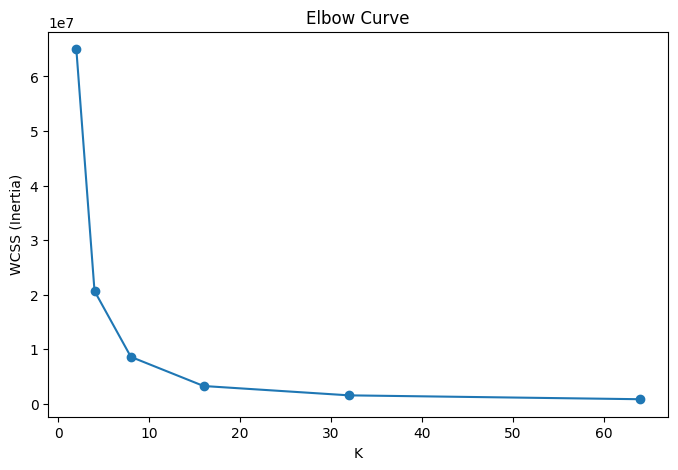

In [5]:
K_values = [2,4,8,16,32,64]
inertias = []

for k in K_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sample_pixels)
    inertias.append(km.inertia_)
    print(f"K={k}, inertia={km.inertia_}")

plt.plot(K_values, inertias, "-o")
plt.xlabel("K")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Curve")
plt.show()


Hyperparameter Tuning:

In [6]:
param_grid = [4, 8, 16, 32]
best_k = None
best_inertia = None

for k in param_grid:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sample_pixels)
    inertia = km.inertia_
    print(f"K={k} → Inertia={inertia}")

    if best_inertia is None or inertia < best_inertia:
        best_inertia = inertia
        best_k = k

print("\nBest K selected:", best_k)


K=4 → Inertia=20689833.58825967
K=8 → Inertia=8628197.00644598
K=16 → Inertia=3290484.3782843407
K=32 → Inertia=1577954.7977766113

Best K selected: 32


Model Training:

Training final model on ALL pixels using K = 32


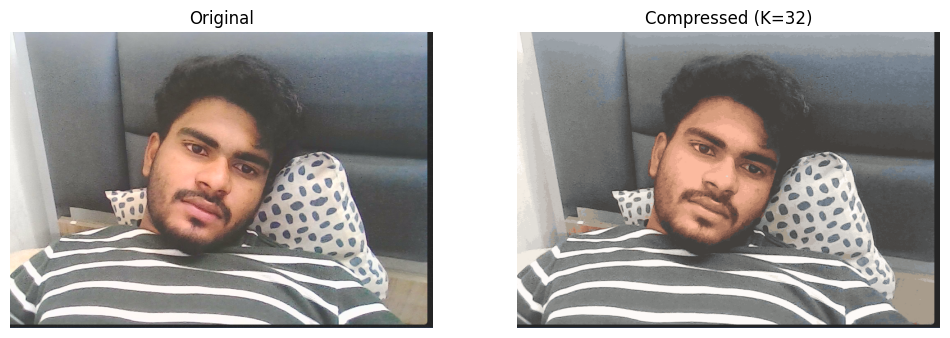

In [7]:
final_k = best_k
print("Training final model on ALL pixels using K =", final_k)

km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
km_final.fit(pixels)

labels = km_final.labels_
centers = km_final.cluster_centers_.astype("uint8")

compressed_pixels = centers[labels]
compressed_img = compressed_pixels.reshape(h, w, 3)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img_np); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(compressed_img); plt.title(f"Compressed (K={final_k})"); plt.axis("off")
plt.show()


Evaluation Metrics:

In [8]:
def mse(a, b):
    return np.mean((a.astype("float64") - b.astype("float64"))**2)

def psnr(orig, recon):
    mse_val = mse(orig, recon)
    if mse_val == 0:
        return float("inf")
    max_pixel = 255.0
    return 20 * math.log10(max_pixel / math.sqrt(mse_val))

orig_size = img_np.nbytes
comp_size = compressed_img.nbytes
compression_ratio = orig_size / comp_size

print("Original size:", orig_size)
print("Compressed size:", comp_size)
print("Compression Ratio:", round(compression_ratio, 2))
print("MSE:", mse(img_np, compressed_img))
print("PSNR:", psnr(img_np, compressed_img))


Original size: 3857685
Compressed size: 3857685
Compression Ratio: 1.0
MSE: 26.07960629237483
PSNR: 33.9677933003271


preview Compressed Images:

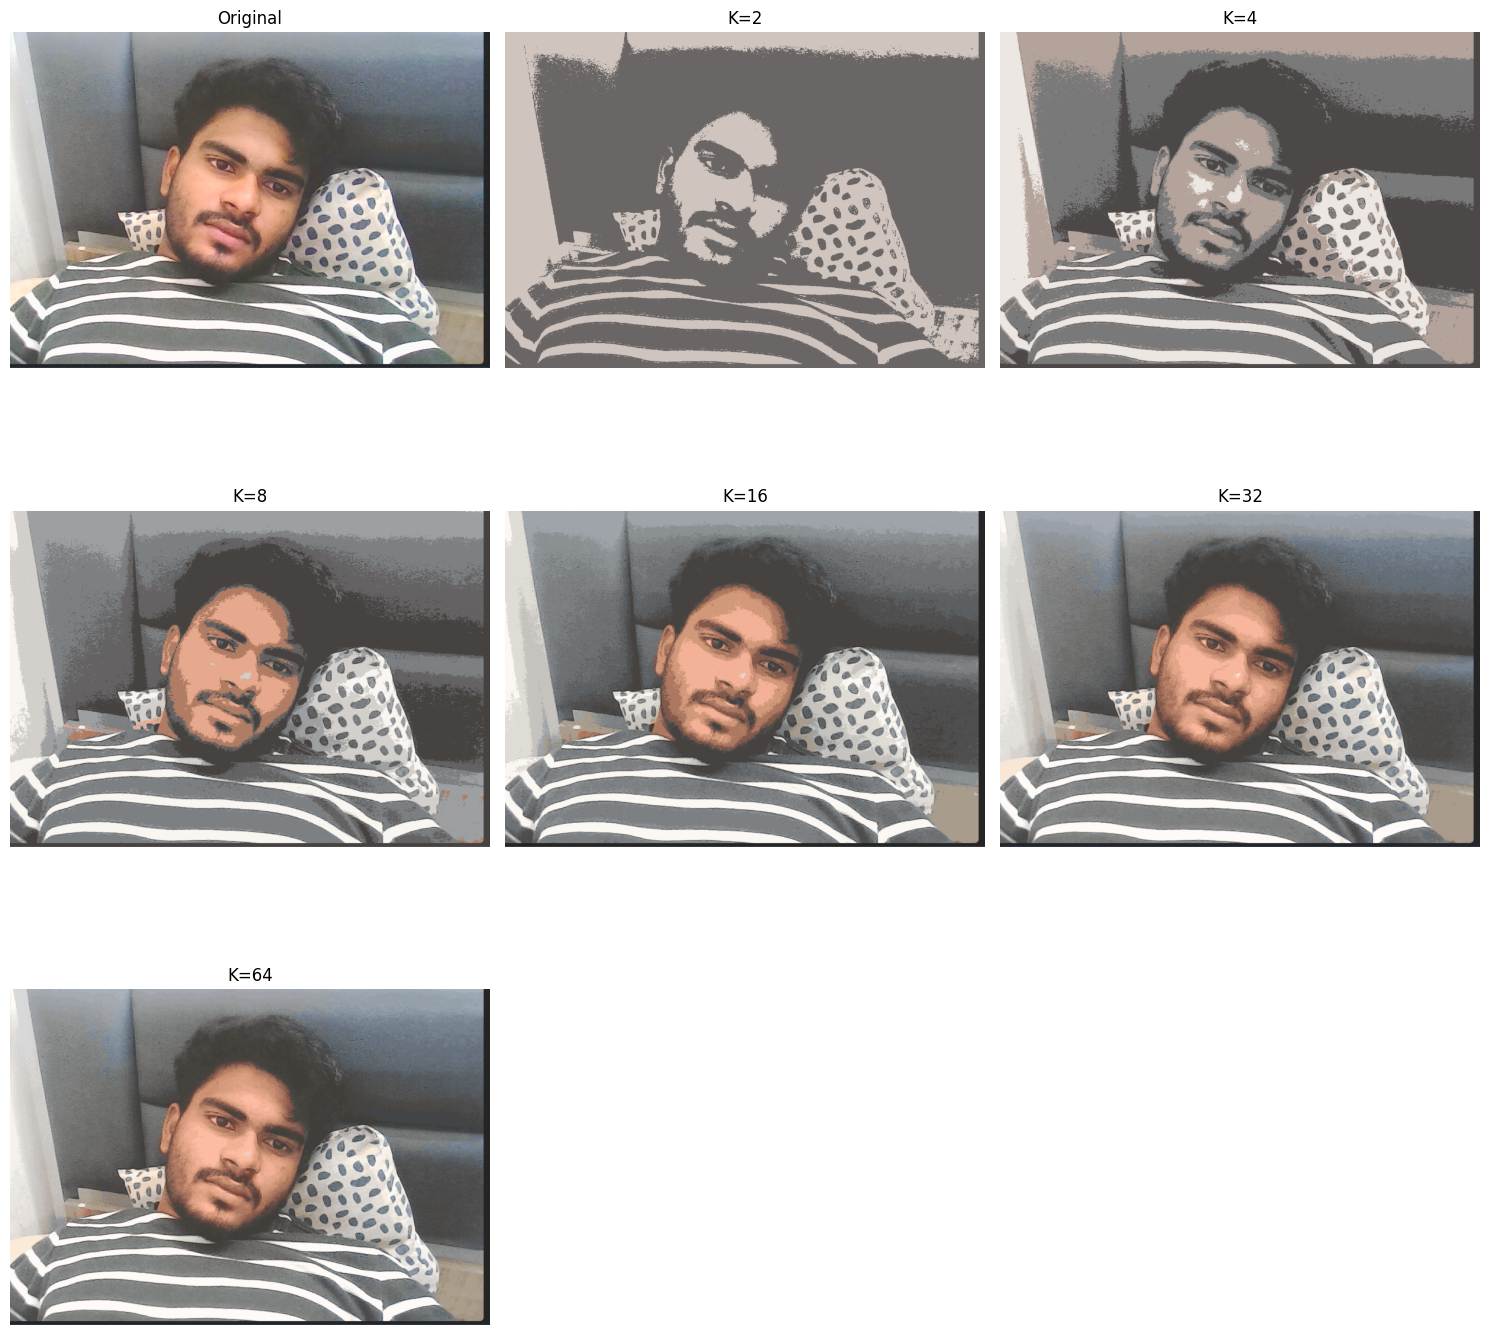

In [9]:
preview_ks = [2, 4, 8, 16, 32, 64]

rows = len(preview_ks) // 3 + 1
plt.figure(figsize=(15, 5*rows))

i = 1
plt.subplot(rows, 3, i); i+=1
plt.imshow(img_np); plt.title("Original"); plt.axis("off")

for k in preview_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(pixels)
    img_k = km.cluster_centers_.astype("uint8")[km.labels_].reshape(h, w, 3)

    plt.subplot(rows, 3, i)
    plt.imshow(img_k)
    plt.title(f"K={k}")
    plt.axis("off")
    i+=1

plt.tight_layout()
plt.show()


Download option:

In [10]:
def save_and_download_k(k):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pixels)
    img_k = km.cluster_centers_.astype("uint8")[km.labels_].reshape(h, w, 3)

    filename = f"compressed_K{k}.png"
    Image.fromarray(img_k).save(filename)
    files.download(filename)
    print("Downloaded:", filename)

# Example:
# save_and_download_k(8)
# save_and_download_k(final_k)
